In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
df.tail()

,Дата,Склад,Контрагент,Номенклатура,Количество
301350,2018-08-31,5,address_173,product_15,0
301351,2018-08-31,5,address_173,product_17,1
301352,2018-08-31,5,address_173,product_18,1
301353,2018-08-31,5,address_173,product_19,0
301354,2018-08-31,5,address_173,product_20,2


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df["Дата"] = pd.to_datetime(df["Дата"], format="%Y-%m-%d")

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby("Дата")["Количество"].sum().reset_index()


Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

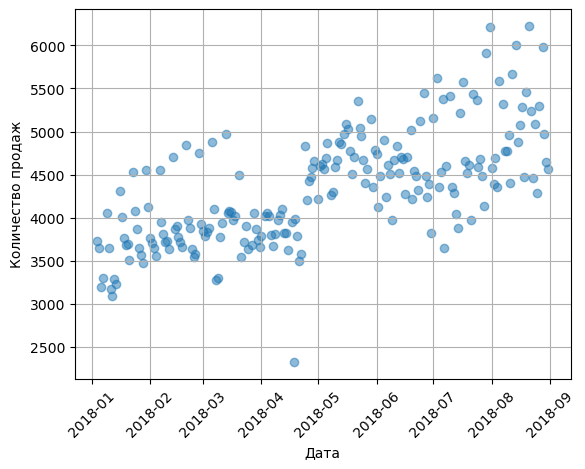

In [8]:
plt.scatter(grouped_df["Дата"], grouped_df["Количество"], alpha=0.5)
plt.grid()
plt.xlabel("Дата")
plt.ylabel("Количество продаж")
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [9]:
#мы видим что кол-во продаж с каждым месяцем становится выше. в апреле небольшая просадка
#так как нет высоких выбросов, но есть низкий выброс, самый низкий по всем датам
#так как это сгрупированные данные, мы видим общее кол-во продаж по дням а не одно
#затем идет рост, в июле-августе самые высокие показатели, но они менее стабильны
#так как имеют сильный разброс по дням, но общий тренд как мы видим это рост относительно января

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
df["Количество"].describe()

count    301355.000000
mean          2.951559
std           2.998154
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         200.000000
Name: Количество, dtype: float64

In [11]:
df[df["Количество"] == 200]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [12]:
filer = df[(df["Дата"].dt.month >= 6) & (df["Дата"].dt.month <= 8) & (df["Дата"].dt.dayofweek == 2) \
    & (df["Склад"] == 3) & (df.index == 261523)]

In [13]:
top_product = filer["Количество"].idxmax()

In [14]:
top_product

np.int64(261523)

In [15]:
filer

,Дата,Склад,Контрагент,Номенклатура,Количество
261523,2018-08-01,3,address_79,product_1,12


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [16]:
df_temp = pd.read_csv("temp_Astana.csv")
df_temp.head()

,Temp,Date_temp
0,-14.0750,2018-01-04
1,-16.8625,2018-01-05
2,-13.3000,2018-01-06
3,-12.7500,2018-01-07
4,-15.4125,2018-01-08


In [18]:
df_temp.info()
df_temp["Date_temp"] = pd.to_datetime(df_temp["Date_temp"], format="%Y-%m-%d")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Temp       241 non-null    float64       
 1   Date_temp  240 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 KB


In [19]:
merged = pd.merge(grouped_df, df_temp, left_on="Дата", right_on="Date_temp", how="inner")

In [20]:
merged = merged.drop(columns=["Date_temp"])

нарисуйте график y=['Количество продаж', 'T'], где Т это температура. А также отдельно график температуры.

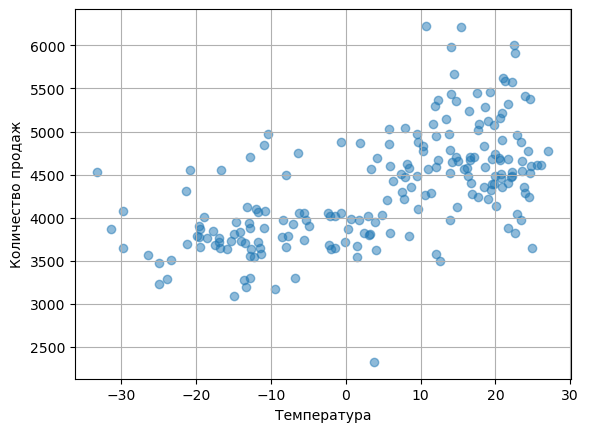

In [21]:
plt.scatter(merged["Temp"],merged["Количество"], alpha = 0.5)
plt.xlabel("Температура")
plt.ylabel("Количество продаж")
plt.grid()
plt.show()

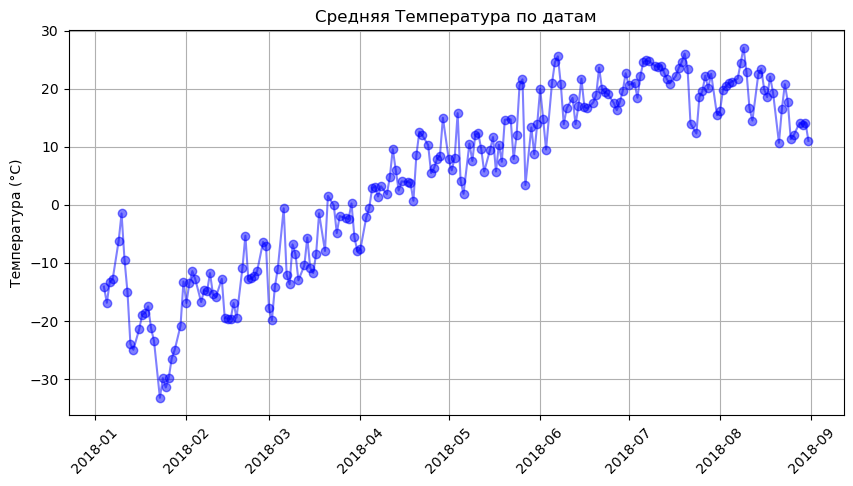

In [35]:
plt.figure(figsize=(10,5))
plt.plot(merged["Дата"], merged["Temp"], color="blue", alpha=0.5, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Температура (°C)")
plt.title("Средняя Температура по датам")
plt.grid(True)
plt.show()